In [11]:
import pandas as pd
import matplotlib.pyplot as plt

#tự động nhận diện cột DATE là datetime và đặt làm index
df = pd.read_csv('vehicle_sales.csv', parse_dates=['DATE'], index_col='DATE')

df.head(-1)

,LTOTALNSA
DATE,
1976-01-01,864.600
1976-02-01,973.300
1976-03-01,1216.100
1976-04-01,1163.200
1976-05-01,1176.100
...,...
2025-10-01,1286.826
2025-11-01,1279.640
2025-12-01,1459.601


In [7]:
#Tạo danh sách ngày theo ngày
dates_daily = pd.date_range(start='2026-04-01', end='2026-04-18', freq='D')
print("Daily:\n", dates_daily)

#Tạo danh sách ngày theo tuần
dates_weekly = pd.date_range(start='2026-04-01', periods=4, freq='W')
print("Weekly:\n", dates_weekly)

#Tạo danh sách ngày theo ngày
dates_monthly = pd.date_range(start='2026-01-01', periods=4, freq='ME')
print("Monthly:\n", dates_monthly)



Daily:
 DatetimeIndex(['2026-04-01', '2026-04-02', '2026-04-03', '2026-04-04',
               '2026-04-05', '2026-04-06', '2026-04-07', '2026-04-08',
               '2026-04-09', '2026-04-10', '2026-04-11', '2026-04-12',
               '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16',
               '2026-04-17', '2026-04-18'],
              dtype='datetime64[us]', freq='D')
Weekly:
 DatetimeIndex(['2026-04-05', '2026-04-12', '2026-04-19', '2026-04-26'], dtype='datetime64[us]', freq='W-SUN')
Monthly:
 DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30'], dtype='datetime64[us]', freq='ME')


In [10]:
#Tính tổng doanh số theo tháng
monthly_sales = df['LTOTALNSA'].resample('ME').sum()

#Tính tổng doanh số theo quý (Quarterly)
quarterly_sales = df['LTOTALNSA'].resample('QE').sum()

print("Dữ liệu theo quý:\n", quarterly_sales.head(-1))

Dữ liệu theo quý:
 DATE
1976-03-31    3054.000
1976-06-30    3564.200
1976-09-30    3149.900
1976-12-31    3201.700
1977-03-31    3424.400
                ...   
2024-12-31    4185.992
2025-03-31    3914.208
2025-06-30    4197.158
2025-09-30    4121.816
2025-12-31    4026.067
Freq: QE-DEC, Name: LTOTALNSA, Length: 200, dtype: float64


In [15]:
#Shift series đi 1 kỳ ( đẩy dl xuống 1 dòng)
df['Previous_Month_Sales'] = df['LTOTALNSA'].shift(1)

#Tính sự chênh lệch so với kỳ trước (Period-over-period differences)
#Hàm .diff(1) cho kq tương dduowg với df['LTOTALNSA'] - df['LTOTALNSA'].shift(1)
df['Sales_Difference'] = df['LTOTALNSA'].diff(1)

df[['LTOTALNSA', 'Previous_Month_Sales', 'Sales_Difference']].head(-1)

,LTOTALNSA,Previous_Month_Sales,Sales_Difference
DATE,,,
1976-01-01,864.600,NaN,NaN
1976-02-01,973.300,864.600,108.700
1976-03-01,1216.100,973.300,242.800
1976-04-01,1163.200,1216.100,-52.900
1976-05-01,1176.100,1163.200,12.900
...,...,...,...
2025-10-01,1286.826,1266.026,20.800
2025-11-01,1279.640,1286.826,-7.186
2025-12-01,1459.601,1279.640,179.961


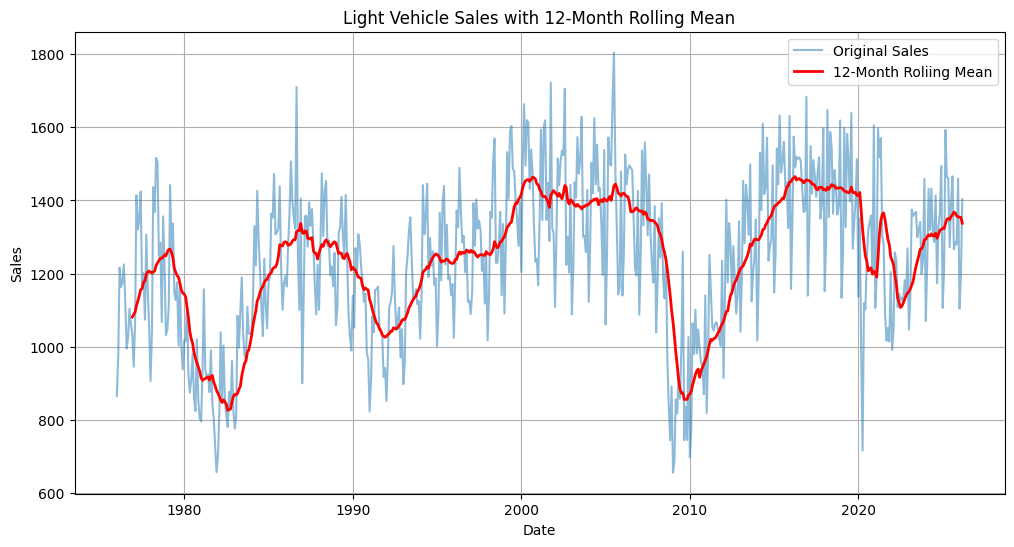

In [16]:
#Vẽ biểu đồ dl gốc và Đường Trung bình cộng (Rolling Mean)
df['Rolling_Mean_12'] = df['LTOTALNSA'].rolling(window=12).mean()

plt.figure(figsize=(12, 6))

plt.plot(df.index, df['LTOTALNSA'], label='Original Sales', alpha=0.5)

#Vẽ đường rolling mean
plt.plot(df.index, df['Rolling_Mean_12'], label='12-Month Roliing Mean', color='red', linewidth=2)

#Trang trí
plt.title('Light Vehicle Sales with 12-Month Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()